In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent

sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

A:\AI_Engineer\ML Projects\Predictive-Maintenance-RUL


In [10]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

from src.data.loader import DataLoader
from src.data.validator import DataValidator
from src.preprocessing.rul_generator import RULGenerator
from src.preprocessing.feature_engineer import FeatureEngineer

from src.preprocessing.feature_selector import FeatureSelector
from src.preprocessing.data_splitter import DataSplitter
from src.preprocessing.feature_scaler import FeatureScaler
from src.preprocessing.preparation_pipeline import DataPreparationPipeline
from src.evaluation.evaluator import RegressionEvaluator
from src.utils.constant import SENSOR_COLUMNS

from src.models.base_trainer import BaseTrainer
from src.explainability.feature_importance import FeatureImportanceAnalyzer
from src.explainability.visualization import ExplainabilityVisualizer
from src.explainability.shap_explainer import SHAPExplainer

from src.config.config import (
    TRAIN_DATA_PATH,
    TEST_DATA_PATH,
    RUL_DATA_PATH
)

from src.config.config import (
    MODELS_DIR,
    PROCESSED_DATA_DIR,
    ARTIFACTS_DIR
)

In [6]:
model_path = ARTIFACTS_DIR / "best_model.pkl"

trainer = BaseTrainer.load(model_path)

2026-08-06 00:05:43 | INFO | base_trainer.py | Line:66 | Loading model from A:\AI_Engineer\ML Projects\Predictive-Maintenance-RUL\artifacts\best_model.pkl


In [11]:
loader = DataLoader(
    train_path=TRAIN_DATA_PATH,
    test_path=TEST_DATA_PATH,
    rul_path=RUL_DATA_PATH,
)

train_df = loader.load_train()
test_df = loader.load_test()
rul_df = loader.load_rul()

2026-08-06 00:09:46 | INFO | loader.py | Line:18 | Reading train_FD004.txt
2026-08-06 00:09:47 | INFO | loader.py | Line:21 | train_FD004.txt Loaded Successfully
2026-08-06 00:09:47 | INFO | loader.py | Line:18 | Reading test_FD004.txt
2026-08-06 00:09:48 | INFO | loader.py | Line:21 | test_FD004.txt Loaded Successfully
2026-08-06 00:09:48 | INFO | loader.py | Line:18 | Reading RUL_FD004.txt
2026-08-06 00:09:48 | INFO | loader.py | Line:21 | RUL_FD004.txt Loaded Successfully


In [12]:
validator = DataValidator(
    train_df,
    test_df,
    rul_df
)

validator.validate_all()

2026-08-06 00:09:49 | INFO | validator.py | Line:40 | Validating training dataset...
2026-08-06 00:09:50 | INFO | validator.py | Line:50 | Validating testing dataset...
2026-08-06 00:09:50 | INFO | validator.py | Line:60 | Validating RUL dataset...


{'train': {'valid': True, 'errors': [], 'warnings': []},
 'test': {'valid': True, 'errors': [], 'warnings': []},
 'rul': {'valid': True, 'errors': [], 'warnings': ['Duplicate rows found.']}}

In [13]:
generator = RULGenerator(train_df=train_df)

train_df = generator.generate(cap=125)

train_df.head()

2026-08-06 00:10:05 | INFO | rul_generator.py | Line:82 | Generating Remaining Useful Life (RUL)...
2026-08-06 00:10:05 | INFO | rul_generator.py | Line:92 | Applying RUL cap = 125
2026-08-06 00:10:05 | INFO | rul_generator.py | Line:96 | RUL generated successfully.


,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670,125
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552,125
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213,125
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176,125
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754,125


In [14]:
engineer = FeatureEngineer(sensor_columns=SENSOR_COLUMNS,lags=[1,2,3],)

feature_df = engineer.transform(train_df)
feature_df.head()

2026-08-06 00:10:14 | INFO | feature_engineer.py | Line:50 | Starting Feature Engineering...
2026-08-06 00:10:14 | INFO | feature_engineer.py | Line:119 | Generating Rolling Mean features...
2026-08-06 00:10:15 | INFO | feature_engineer.py | Line:148 | Generating Rolling Std features...
2026-08-06 00:10:16 | INFO | feature_engineer.py | Line:179 | Generating Lag Features...
2026-08-06 00:10:16 | INFO | feature_engineer.py | Line:205 | Generating Rate of Change features...
2026-08-06 00:10:16 | INFO | feature_engineer.py | Line:61 | Feature Engineering completed successfully.


,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12_diff,sensor_13_diff,sensor_14_diff,sensor_15_diff,sensor_16_diff,sensor_17_diff,sensor_18_diff,sensor_19_diff,sensor_20_diff,sensor_21_diff
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,182.81,-0.26,-28.70,-0.1422,0.0,31.0,112.0,0.00,13.75,8.2882
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,-182.97,0.24,20.49,0.2094,0.0,-32.0,-112.0,0.00,-13.89,-8.2339
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,0.18,0.05,9.43,-0.0638,0.0,-1.0,0.0,0.00,0.06,-0.0037
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,34.31,-359.94,-210.25,1.4997,0.0,-23.0,-297.0,-15.07,3.49,2.2578


In [15]:
pipeline = DataPreparationPipeline(

    splitter=DataSplitter(
        test_size=0.2,
    ),

    selector=FeatureSelector(

        target_column="RUL",

        drop_columns=[
            "unit_number",
        ],

    ),

    scaler=FeatureScaler(),

)

In [16]:
X_train, X_val, y_train, y_val = pipeline.prepare(
    feature_df
)

2026-08-06 00:10:35 | INFO | preparation_pipeline.py | Line:37 | Starting Data Preparation Pipeline...
2026-08-06 00:10:35 | INFO | data_splitter.py | Line:35 | Starting engine-based train/validation split...
2026-08-06 00:10:36 | INFO | data_splitter.py | Line:67 | Train Engines: 199 | Validation Engines: 50
2026-08-06 00:10:36 | INFO | data_splitter.py | Line:72 | Data splitting completed successfully.
2026-08-06 00:10:36 | INFO | feature_selector.py | Line:29 | Starting Feature Selection...
2026-08-06 00:10:36 | INFO | feature_selector.py | Line:40 | Feature Selection completed successfully.
2026-08-06 00:10:36 | INFO | feature_selector.py | Line:29 | Starting Feature Selection...
2026-08-06 00:10:36 | INFO | feature_selector.py | Line:40 | Feature Selection completed successfully.
2026-08-06 00:10:36 | INFO | feature_scaler.py | Line:33 | Fitting Feature Scaler...
2026-08-06 00:10:36 | INFO | feature_scaler.py | Line:37 | Feature Scaler fitted successfully.
2026-08-06 00:10:36 | IN

In [17]:
analyzer = FeatureImportanceAnalyzer()

importance_df = analyzer.get_importance(
    model=trainer,
    feature_names=X_train.columns,
)

importance_df.head(20)

2026-08-06 00:11:14 | INFO | feature_importance.py | Line:16 | Computing feature importance...
2026-08-06 00:11:14 | INFO | feature_importance.py | Line:40 | Feature importance computed successfully.


,feature,importance
0,time_in_cycles,16.663554
1,sensor_13,8.669868
2,sensor_13_lag_1,5.920972
3,sensor_13_lag_3,5.592521
4,sensor_13_lag_2,5.462192
5,sensor_11,4.696556
6,sensor_15_lag_1,4.581563
7,sensor_15,4.515064
8,sensor_11_lag_3,3.859262
9,sensor_6,3.341500


In [18]:
print(f"Total Features      : {len(importance_df)}")

print(
    f"Zero Importance     : "
    f"{len(analyzer.get_zero_importance(importance_df))}"
)

print(
    f"Importance < 0.001  : "
    f"{len(analyzer.get_low_importance(importance_df))}"
)

Total Features      : 151
Zero Importance     : 20
Importance < 0.001  : 20


In [19]:
top10 = analyzer.get_top_features(
    importance_df,
    top_n=10,
)

top10

,feature,importance
0,time_in_cycles,16.663554
1,sensor_13,8.669868
2,sensor_13_lag_1,5.920972
3,sensor_13_lag_3,5.592521
4,sensor_13_lag_2,5.462192
5,sensor_11,4.696556
6,sensor_15_lag_1,4.581563
7,sensor_15,4.515064
8,sensor_11_lag_3,3.859262
9,sensor_6,3.341500


In [20]:
top50 = analyzer.get_top_features(
    importance_df,
    top_n=50,
)

top50

,feature,importance
0,time_in_cycles,16.663554
1,sensor_13,8.669868
2,sensor_13_lag_1,5.920972
3,sensor_13_lag_3,5.592521
4,sensor_13_lag_2,5.462192
5,sensor_11,4.696556
6,sensor_15_lag_1,4.581563
7,sensor_15,4.515064
8,sensor_11_lag_3,3.859262
9,sensor_6,3.341500


In [21]:
visualizer = ExplainabilityVisualizer()

2026-08-06 00:12:34 | INFO | visualization.py | Line:61 | Saved plot to A:\AI_Engineer\ML Projects\Predictive-Maintenance-RUL\artifacts\plots\top_50_feature_importance.png


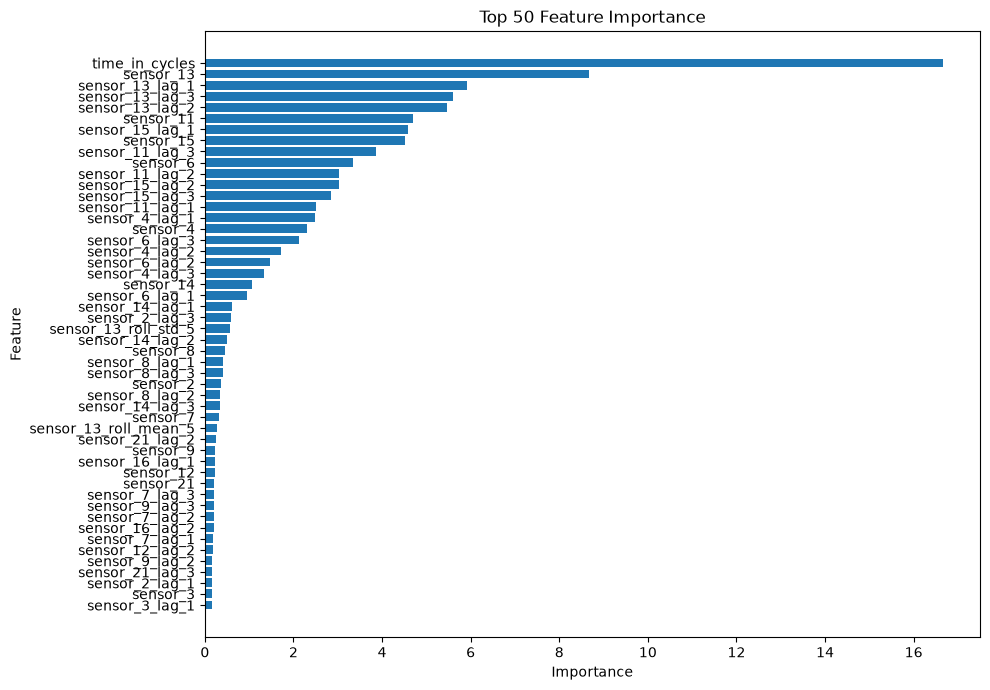

In [22]:
visualizer.plot_feature_importance(
    importance_df,
    top_n=50,
)

In [23]:
explainer = SHAPExplainer(trainer)

shap_values = explainer.compute(X_val)

2026-08-06 00:13:17 | INFO | shap_explainer.py | Line:22 | Computing SHAP values...


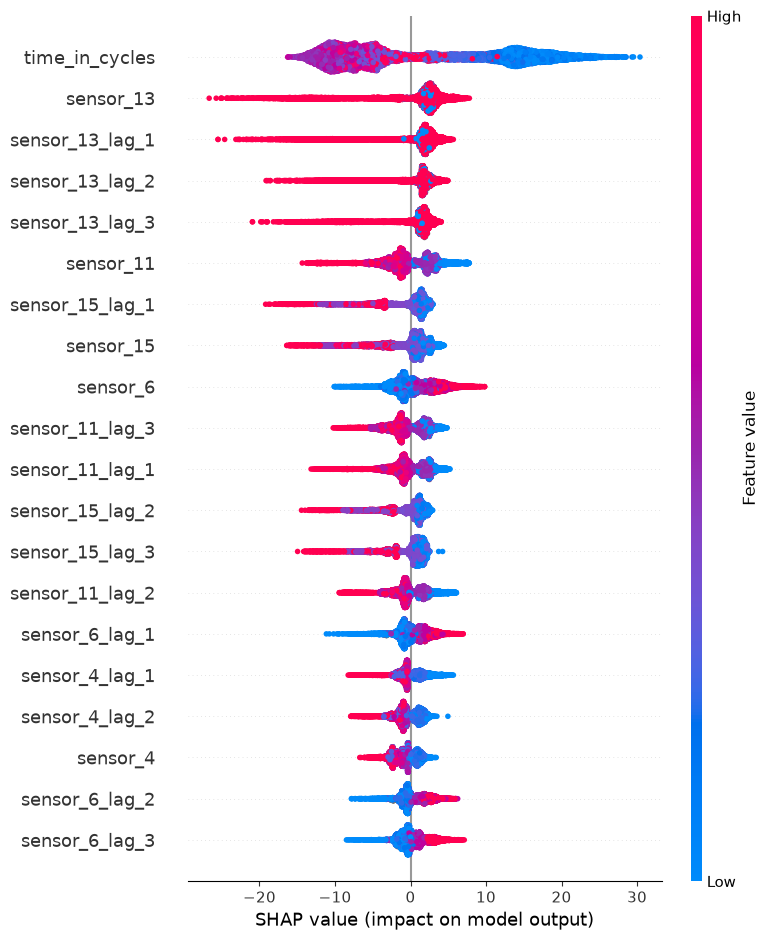

In [24]:
explainer.summary_plot(
    shap_values,
    X_val,
)

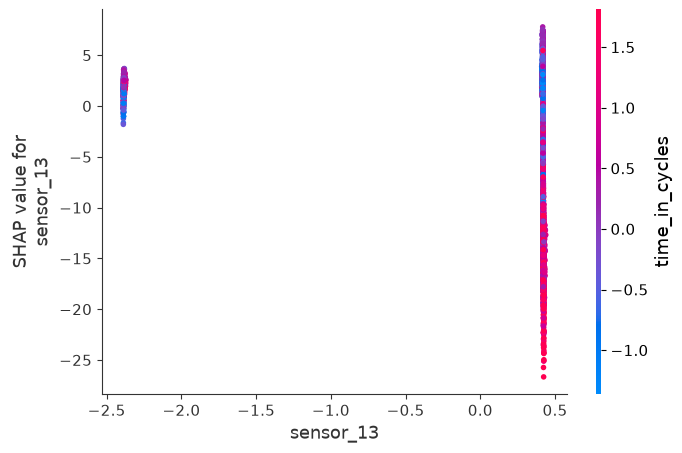

In [26]:
explainer.dependence_plot(
    feature="sensor_13",
    shap_values=shap_values,
    X=X_val,
)

In [29]:
lag = importance_df["feature"].str.contains("_lag").sum()

rolling = importance_df["feature"].str.contains("_roll").sum()

diff = importance_df["feature"].str.contains("_diff").sum()

raw = len(importance_df) - lag - rolling - diff

print(f"Raw Features      : {raw}")
print(f"Lag Features      : {lag}")
print(f"Rolling Features  : {rolling}")
print(f"Diff Features     : {diff}")

Raw Features      : 25
Lag Features      : 63
Rolling Features  : 42
Diff Features     : 21


In [30]:
raw_importance = importance_df[
    ~importance_df["feature"].str.contains("_lag|_roll|_diff")
]["importance"].sum()

lag_importance = importance_df[
    importance_df["feature"].str.contains("_lag")
]["importance"].sum()

rolling_importance = importance_df[
    importance_df["feature"].str.contains("_roll")
]["importance"].sum()

diff_importance = importance_df[
    importance_df["feature"].str.contains("_diff")
]["importance"].sum()

print(f"Raw      : {raw_importance:.3f}")
print(f"Lag      : {lag_importance:.3f}")
print(f"Rolling  : {rolling_importance:.3f}")
print(f"Diff     : {diff_importance:.3f}")

Raw      : 43.732
Lag      : 53.999
Rolling  : 1.939
Diff     : 0.330


In [28]:
importance_df.to_csv(
    MODELS_DIR / "feature_importance.csv",
    index=False,
)

print("Feature importance saved successfully.")

Feature importance saved successfully.


# Engineering Observations

## Feature Importance

- To be completed after analyzing the results.

## Weak Features

- To be completed after identifying low-importance features.

## SHAP Analysis

- To be completed after reviewing SHAP summary and dependence plots.

## Engineering Decisions

- Determine whether feature reduction is justified.
- Identify the most influential sensor groups.
- Compare engineered features with original sensor measurements.
- Prepare for Sprint 10: Feature Selection.